<a href="https://colab.research.google.com/github/Olya-Shulga/Univercity/blob/main/neural_networks/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%965_%D0%90%D1%80%D1%85%D0%B8%D1%82%D0%B5%D0%BA%D1%82%D1%83%D1%80%D1%8B_%D0%9D%D0%A1_%D0%B8_Transfer_Learning_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практическая работа №5. Архитектуры CNN и Transfer Learning.ipynb**

## **Задание 1. Использование предобученной модели**

### **1.1. Выберите и импортируйте предобученную модель СНС для решения задач классификации из имеющихся в Keras: https://keras.io/api/applications/**

In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input, decode_predictions
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
import requests
from PIL import Image
from io import BytesIO
import os

In [ ]:
model = VGG16(weights='imagenet')
print("Модель VGG16 загружена")
print(f"Архитектура модели: {model.summary()}")

553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Модель VGG16 загружена


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 1000)           │     4,097,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,357,544 (527.79 MB)

 Trainable params: 138,357,544 (527.79 MB)

 Non-trainable params: 0 (0.00 B)

Архитектура модели: None


### **1.2. Загрузите из сети Интернет 5 изображений с разными классами, из тех, что приведены в [списке](https://gist.github.com/yrevar/942d3a0ac09ec9e5eb3a), и сохраните их представление в список images**

In [ ]:
image_urls = [
    "https://i.pinimg.com/736x/75/23/94/752394c7de50a4812702fbd1e01531bb.jpg",
    "https://i.pinimg.com/1200x/b7/18/80/b71880d1b7e8b005b20c7594080804b2.jpg",
    "https://i.pinimg.com/736x/f8/fb/6c/f8fb6c8058a48ef342949fa603b1efc4.jpg",
    "https://i.pinimg.com/originals/d3/78/bd/d378bd328d2eab36decc78085c35ffd0.jpg",
    "https://i.pinimg.com/originals/64/cc/c8/64ccc84f80aed3bb833c971918aac609.jpg"
]

images = []  # список для хранения изображений

def load_image_from_url(url):
    """Загрузка изображения по URL"""
    try:
        response = requests.get(url, timeout=10)
        img = Image.open(BytesIO(response.content))
        return img
    except Exception as e:
        print(f"Ошибка загрузки {url}: {e}")
        return None

# Загружаем изображения
for i, url in enumerate(image_urls):
    img = load_image_from_url(url)
    if img is not None:
        images.append(img)
        print(f"Изображение {i+1} загружено")
    else:
        print(f"Не удалось загрузить изображение {i+1}")

print(f"\nВсего загружено изображений: {len(images)}")

Изображение 1 загружено
Изображение 2 загружено
Изображение 3 загружено
Изображение 4 загружено
Изображение 5 загружено

Всего загружено изображений: 5


### **1.3. Напишите функцию, принимающую на вход список с исходными изображениями и возвращающую список с преобразованными изображениями под формат входных данных выбранной Вами модели СНС (нормализация).**

(Не забудьте создать независимую копию исходного списка в теле функции, для обработки именно независимой копии, а не оригинального списка)

In [ ]:
def preprocess_images(images_list, target_size=(224, 224)):
    """
    Преобразование изображений под формат входных данных модели VGG16

    Args:
        images_list: список изображений PIL Image
        target_size: целевой размер изображений

    Returns:
        list: список преобразованных изображений (numpy массивы)
    """
    # Создаем независимую копию исходного списка
    processed_images = []

    for img in images_list:
        # Создаем копию изображения
        img_copy = img.copy()

        # Изменяем размер до нужного
        img_resized = img_copy.resize(target_size)

        # Конвертируем в numpy массив
        img_array = image.img_to_array(img_resized)

        # Добавляем измерение для batch
        img_array = np.expand_dims(img_array, axis=0)

        # Применяем предобработку для VGG16
        img_preprocessed = preprocess_input(img_array)

        processed_images.append(img_preprocessed)

    return processed_images

processed_images = preprocess_images(images)
print(f"Обработано {len(processed_images)} изображений")
print(f"Размер одного обработанного изображения: {processed_images[0].shape}")

Обработано 5 изображений
Размер одного обработанного изображения: (1, 224, 224, 3)


### **1.5. Выведите изображения и соответствующие им классы (как в примере из теории)**

35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


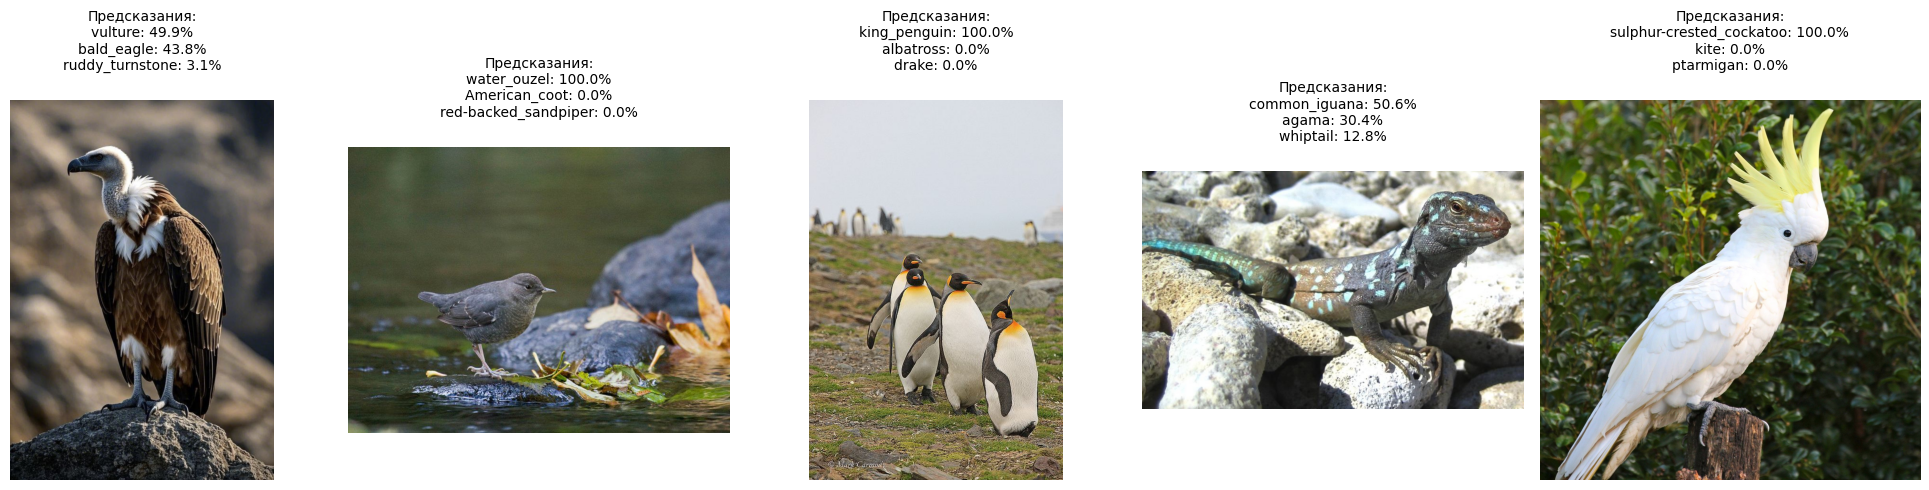

In [ ]:
def predict_and_display(images_original, processed_images, model, top_k=3):
    """
    Предсказание классов и отображение изображений с результатами

    Args:
        images_original: список оригинальных изображений
        processed_images: список обработанных изображений
        model: предобученная модель
        top_k: количество топ-предсказаний
    """
    # Создаем фигуру для отображения
    fig, axes = plt.subplots(1, len(images_original), figsize=(20, 5))
    if len(images_original) == 1:
        axes = [axes]

    for i, (img_orig, img_proc) in enumerate(zip(images_original, processed_images)):
        # Предсказание
        predictions = model.predict(img_proc, verbose=0)

        # Декодируем предсказания
        decoded_preds = decode_predictions(predictions, top=top_k)[0]

        # Отображаем изображение
        axes[i].imshow(img_orig)
        axes[i].axis('off')

        # Формируем текст с предсказаниями
        pred_text = "Предсказания:\n"
        for j, (imagenet_id, label, score) in enumerate(decoded_preds):
            pred_text += f"{label}: {score*100:.1f}%\n"

        axes[i].set_title(pred_text, fontsize=10, pad=10)

    plt.tight_layout()
    plt.show()

# Выполняем предсказание и отображение
predict_and_display(images, processed_images, model)

## **Задание 2. Использование обученной модели для работы со своим датасетом**

### **2.1. Выберите и импортируйте предобученную модель СНС для решения задач классификации из имеющихся в Keras: https://keras.io/api/applications/**

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import matplotlib.pyplot as plt
import numpy as np
import os
import cv2
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer
from imutils import paths
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
import tensorflow as tf
help(tf.keras.applications)

Help on package tensorflow.keras.applications in tensorflow.keras:

NAME
    tensorflow.keras.applications - DO NOT EDIT.

DESCRIPTION
    This file was autogenerated. Do not edit it by hand,
    since your modifications would be overwritten.

PACKAGE CONTENTS
    convnext (package)
    densenet (package)
    efficientnet (package)
    efficientnet_v2 (package)
    imagenet_utils (package)
    inception_resnet_v2 (package)
    inception_v3 (package)
    mobilenet (package)
    mobilenet_v2 (package)
    mobilenet_v3 (package)
    nasnet (package)
    resnet (package)
    resnet50 (package)
    resnet_v2 (package)
    vgg16 (package)
    vgg19 (package)
    xception (package)

FILE
    /usr/local/lib/python3.12/dist-packages/keras/_tf_keras/keras/applications/__init__.py




In [ ]:
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
print("Базовая модель MobileNetV2 загружена")
print(f"Количество слоев в базовой модели: {len(base_model.layers)}")
base_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Базовая модель MobileNetV2 загружена
Количество слоев в базовой модели: 154


Model: "mobilenetv2_1.00_224"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 2,223,872 (8.48 MB)

 Non-trainable params: 34,112 (133.25 KB)

### **2.2. Подготовка тренировочных данных. Разделение на обучающую и тестовую выборку**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
DATASET_PATH = "/content/drive/MyDrive/my_photos"
data_dir = DATASET_PATH
IMAGE_SIZE = (224, 224)

# Инициализация данных
data = []
labels = []

# Перебор классов
class_names = sorted(os.listdir(DATASET_PATH))
print(f"Классы: {class_names}")

for class_name in class_names:
    class_path = os.path.join(DATASET_PATH, class_name)
    image_paths = list(paths.list_images(class_path))

    # Берем первые 1010 изображений каждого класса
    image_paths = image_paths[:1010]

    for img_path in image_paths:
        # Загрузка и предобработка
        image = cv2.imread(img_path)
        if image is not None:
            image = cv2.resize(image, IMAGE_SIZE)
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            data.append(image)
            labels.append(class_name)
        else:
            print(f"Не удалось загрузить: {img_path}")

print(f"Загружено {len(data)} изображений")

# Нормализация в [0, 1]
data = np.array(data, dtype="float") / 255.0
labels = np.array(labels)
print(f"Форма данных: {data.shape}, метки: {labels.shape}")

(trainX, testX, trainY, testY) = train_test_split(data, labels,
                                                  test_size=0.25,
                                                  stratify=labels,
                                                  random_state=42)

lb = LabelBinarizer()
trainY = lb.fit_transform(trainY)
testY = lb.transform(testY)

print(f"Обучающая выборка: {trainX.shape}")
print(f"Тестовая выборка: {testX.shape}")

Классы: ['cat', 'dog', 'horse']
Загружено 3030 изображений
Форма данных: (3030, 224, 224, 3), метки: (3030,)
Обучающая выборка: (2272, 224, 224, 3)
Тестовая выборка: (758, 224, 224, 3)


In [ ]:
IMG_HEIGHT, IMG_WIDTH = 224, 224
BATCH_SIZE = 128
EPOCHS = 10
AUTOTUNE = tf.data.AUTOTUNE

In [ ]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

def my_custom_preprocessing(image, label):
    image = tf.cast(image, tf.float32)
    image = preprocess_input(image)
    return image, label

In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

Found 3129 files belonging to 3 classes.
Using 2504 files for training.
Found 3129 files belonging to 3 classes.
Using 625 files for validation.


In [ ]:
train_ds = train_ds.map(my_custom_preprocessing, num_parallel_calls=AUTOTUNE)
val_ds = val_ds.map(my_custom_preprocessing, num_parallel_calls=AUTOTUNE)

In [ ]:
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

### **2.3. Обучение своей модели на основе предобученной модели** "*название модели, выбранной в п.2.1.*"

In [ ]:
# Замораживаем базовые слои предобученной модели
base_model.trainable = False

# Создаем модель с новыми верхними слоями
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(len(lb.classes_), activation='softmax')
])

# Компилируем модель
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

print(model.summary())

# Callbacks для улучшения обучения
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint('best_model.keras', monitor='val_accuracy', save_best_only=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=0.00001)
]

# Обучение модели
history = model.fit(
    train_ds,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=callbacks,
    verbose=1,
    shuffle=True
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,619,203 (9.99 MB)

 Trainable params: 361,219 (1.38 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

None
Epoch 1/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 220s 9s/step - accuracy: 0.5455 - loss: 1.0165 - val_accuracy: 0.8992 - val_loss: 0.5057 - learning_rate: 1.0000e-04
Epoch 2/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 153s 8s/step - accuracy: 0.8063 - loss: 0.5114 - val_accuracy: 0.9520 - val_loss: 0.2468 - learning_rate: 1.0000e-04
Epoch 3/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 153s 8s/step - accuracy: 0.9010 - loss: 0.3099 - val_accuracy: 0.9664 - val_loss: 0.1509 - learning_rate: 1.0000e-04
Epoch 4/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 200s 8s/step - accuracy: 0.9305 - loss: 0.2197 - val_accuracy: 0.9712 - val_loss: 0.1076 - learning_rate: 1.0000e-04
Epoch 5/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 214s 8s/step - accuracy: 0.9537 - loss: 0.1598 - val_accuracy: 0.9728 - val_loss: 0.0878 - learning_rate: 1.0000e-04
Epoch 6/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 191s 8s/step - accuracy: 0.9645 - loss: 0.1266 - val_accuracy: 0.9744 - val_loss: 0.0753 - learning_rate: 1.0000e-04
Epoch 7/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 152s 8s/step - accuracy: 0.

### **2.4. Визуализация процесса обучения модели**

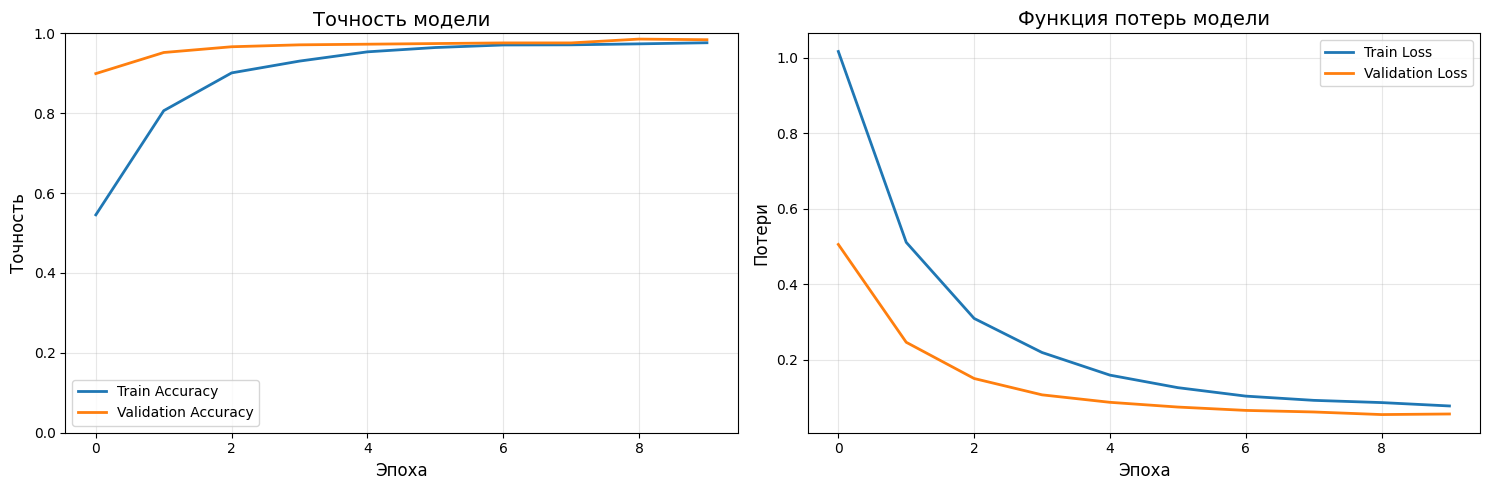

In [ ]:
# Визуализация процесса обучения
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# График точности
axes[0].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[0].set_title('Точность модели', fontsize=14)
axes[0].set_xlabel('Эпоха', fontsize=12)
axes[0].set_ylabel('Точность', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim([0, 1])

# График потерь
axes[1].plot(history.history['loss'], label='Train Loss', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[1].set_title('Функция потерь модели', fontsize=14)
axes[1].set_xlabel('Эпоха', fontsize=12)
axes[1].set_ylabel('Потери', fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### **2.5. Подготовьте набор проверочных данных (examples)**

24/24 ━━━━━━━━━━━━━━━━━━━━ 38s 1s/step


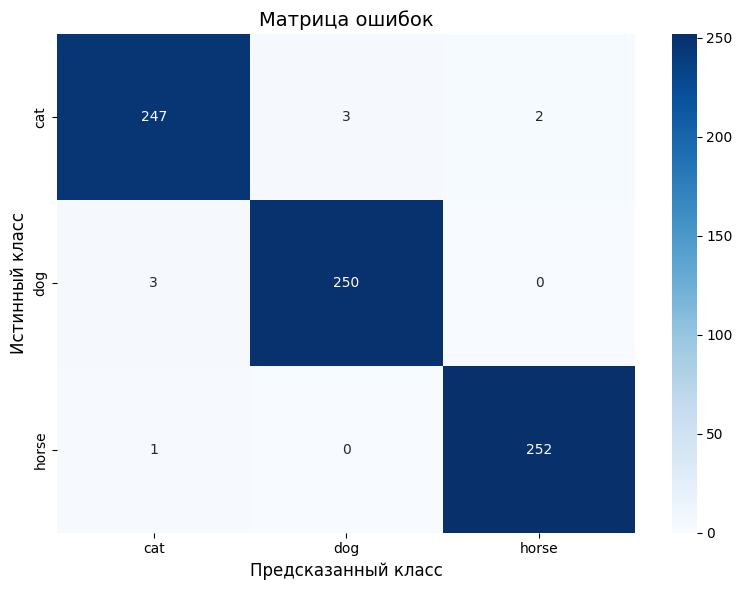


КЛАССИФИКАЦИОННЫЙ ОТЧЕТ
              precision    recall  f1-score   support

         cat       0.98      0.98      0.98       252
         dog       0.99      0.99      0.99       253
       horse       0.99      1.00      0.99       253

    accuracy                           0.99       758
   macro avg       0.99      0.99      0.99       758
weighted avg       0.99      0.99      0.99       758



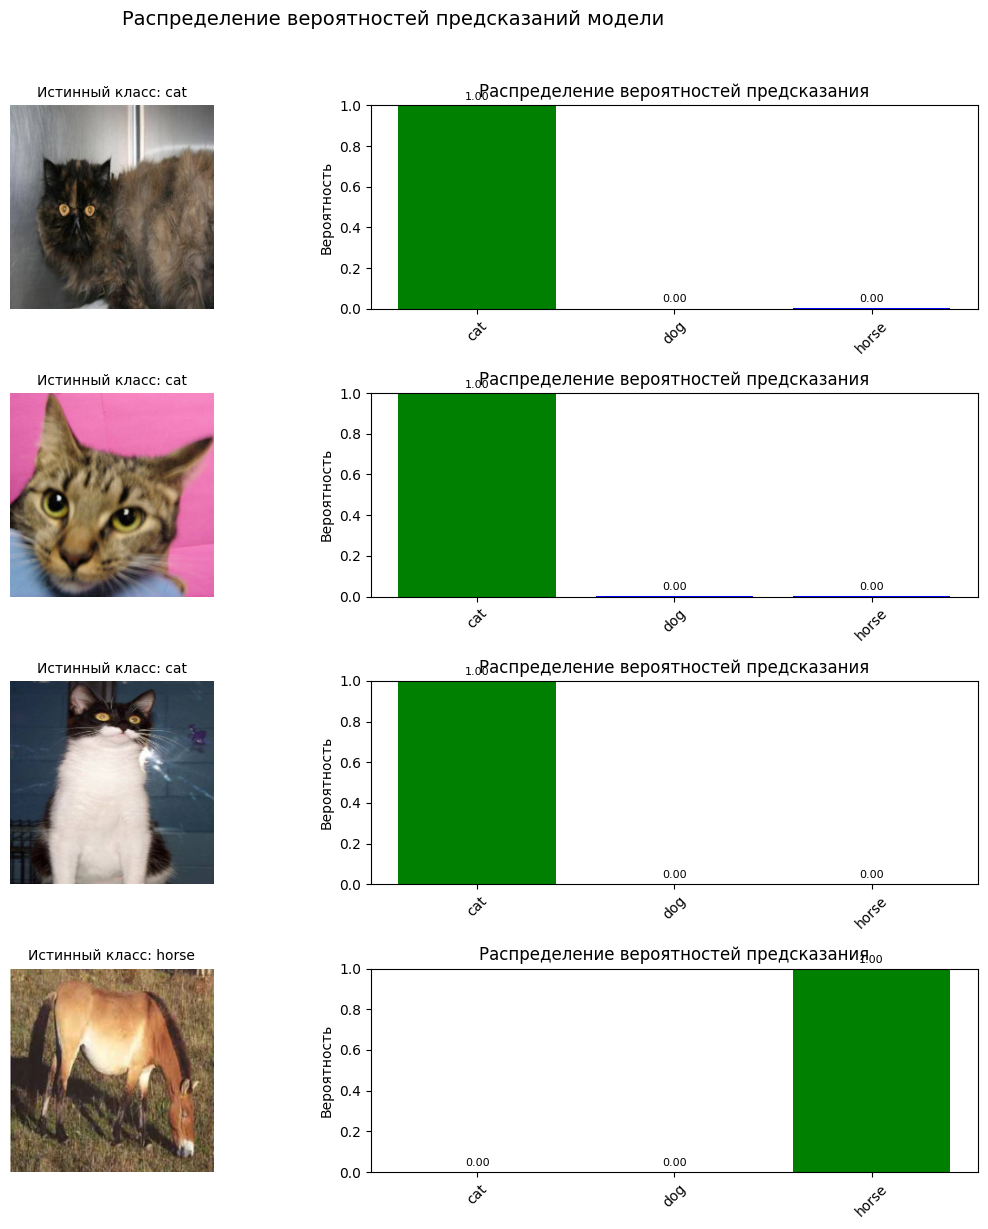


 Модель сохранена как 'trained_model.keras'
Метки классов сохранены в 'class_labels.pkl'


In [ ]:
# Получение предсказаний на тестовой выборке
predictions = model.predict(testX)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(testY, axis=1)

# Матрица ошибок
cm = confusion_matrix(true_classes, predicted_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=lb.classes_, yticklabels=lb.classes_)
plt.title('Матрица ошибок', fontsize=14)
plt.xlabel('Предсказанный класс', fontsize=12)
plt.ylabel('Истинный класс', fontsize=12)
plt.tight_layout()
plt.show()

# Классификационный отчет
print("\n" + "="*60)
print("КЛАССИФИКАЦИОННЫЙ ОТЧЕТ")
print("="*60)
print(classification_report(true_classes, predicted_classes, target_names=lb.classes_))

# Визуализация распределения вероятностей
def visualize_probability_distribution(model, testX, testY, class_names, num_samples=4):
    """
    Визуализация распределения вероятностей для проверочных примеров
    """
    indices = np.random.choice(len(testX), num_samples, replace=False)

    fig, axes = plt.subplots(num_samples, 2, figsize=(12, 3*num_samples))

    for i, sample_idx in enumerate(indices):
        # Изображение
        img = testX[sample_idx]
        true_label = np.argmax(testY[sample_idx])

        # Предсказание
        pred = model.predict(img.reshape(1, 224, 224, 3), verbose=0)

        # Отображаем изображение
        axes[i, 0].imshow(img)
        axes[i, 0].axis('off')
        axes[i, 0].set_title(f"Истинный класс: {class_names[true_label]}", fontsize=10)

        # Отображаем распределение вероятностей
        bars = axes[i, 1].bar(class_names, pred[0], color=['green' if j == true_label else 'blue' for j in range(len(class_names))])
        axes[i, 1].set_ylabel('Вероятность')
        axes[i, 1].set_title('Распределение вероятностей предсказания')
        axes[i, 1].tick_params(axis='x', rotation=45)
        axes[i, 1].set_ylim([0, 1])

        # Добавляем значения на график
        for bar, prob in zip(bars, pred[0]):
            axes[i, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                          f'{prob:.2f}', ha='center', va='bottom', fontsize=8)

    plt.suptitle('Распределение вероятностей предсказаний модели', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

# Визуализируем распределение вероятностей
visualize_probability_distribution(model, testX, testY, lb.classes_, num_samples=4)

# Сохраняем модель
model.save('trained_model.keras')
print("\n Модель сохранена как 'trained_model.keras'")

# Сохраняем метки классов
import pickle
with open('class_labels.pkl', 'wb') as f:
    pickle.dump(lb.classes_, f)
print("Метки классов сохранены в 'class_labels.pkl'")

### **2.6. Реализуйте графический интерфейс для взаимодействия с обученной моделью, используя [Gradio](https://www.gradio.app/guides/image-classification-in-tensorflow) или люое другое решение.**



Если выбрали Gradio, то в качестве примеров (параметр examples в Gradio), используйте изображения из списка images (п.1.2.)

In [ ]:
!pip install gradio

In [ ]:
import numpy as np
import cv2
from PIL import Image

def predict_image(img):
    img = np.array(img)
    img = cv2.resize(img, (380, 380))
    img = img / 255.0
    img = np.expand_dims(img, axis=0)

    preds = model.predict(img)[0]

    return {
        class_names[i]: float(preds[i])
        for i in range(len(class_names))
    }

In [ ]:
import gradio as gr

interface = gr.Interface(
    fn=predict_image,
    inputs=gr.Image(type="pil"),
    outputs="label",
    title="Pets Classifier",
    description="Загрузи изображение лошади, кошки или собаки"
)

In [ ]:
interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://82dcd1b92bde502d95.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


KeyboardInterrupt: 

## **Задание 3. Классификация набора пространственных данных EuroSat (для магистров)**

- Ссылка на датасет: https://github.com/phelber/eurosat

- Описание на kaggle: https://www.kaggle.com/datasets/apollo2506/eurosat-dataset

В этом задании Вам будет предоставлен набор данных EuroSat, который содержит снимки земной поверхности, снятые спутником Sentinel-2. Вам нужно будет обучить модель для классификации этих изображений на 10 классов, представляющих различные типы земного покрова.

### **3.1. Загрузка данных:**
  * [Скачайте](https://madm.dfki.de/files/sentinel/EuroSAT.zip) набор данных EuroSat
  * Разделите данные на обучающую, валидационную и тестовую выборки.



In [ ]:
!wget --no-check-certificate https://madm.dfki.de/files/sentinel/EuroSAT.zip

--2026-04-23 12:37:40--  https://madm.dfki.de/files/sentinel/EuroSAT.zip
Resolving madm.dfki.de (madm.dfki.de)... 131.246.195.183
Connecting to madm.dfki.de (madm.dfki.de)|131.246.195.183|:443... connected.
  Unable to locally verify the issuer's authority.
HTTP request sent, awaiting response... 200 OK
Length: 94280567 (90M) [application/zip]
Saving to: ‘EuroSAT.zip’

EuroSAT.zip         100%[===================>]  89.91M  18.8MB/s    in 5.9s    

2026-04-23 12:37:47 (15.2 MB/s) - ‘EuroSAT.zip’ saved [94280567/94280567]



In [ ]:
import zipfile

with zipfile.ZipFile("EuroSAT.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/eurosat")

In [ ]:
import tensorflow as tf
dataset_path = "/content/eurosat/2750"

train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(224, 224),
    batch_size=16
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(224, 224),
    batch_size=16
)

Found 27000 files belonging to 10 classes.
Using 21600 files for training.
Found 27000 files belonging to 10 classes.
Using 5400 files for validation.


In [ ]:
class_names = train_ds.class_names
print(class_names)

['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


### **3.2. Выбор архитектуры нейронной сети:**
  * Выберите архитектуру нейронной сети, основанную на трансферном обучении, например, ResNet50, VGG16 или InceptionV3 ([полный список](https://keras.io/api/applications/)).
  * Загрузите предобученную модель выбранной архитектуры.


In [ ]:
from tensorflow.keras.applications import ResNet50

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


### **3.3. Дообучение модели:**
  * Добавьте к предобученной модели несколько слоев для классификации изображений EuroSat.
  * Обучите модель на обучающей выборке.

In [ ]:
from tensorflow.keras import layers, models
from tensorflow.keras.applications.resnet50 import preprocess_input

inputs = tf.keras.Input(shape=(224, 224, 3))

x = preprocess_input(inputs)

# базовая модель
x = base_model(x, training=False)

# классификатор
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)

x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)

outputs = layers.Dense(10, activation='softmax')(x)

model = models.Model(inputs, outputs)

In [ ]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

checkpoint = ModelCheckpoint(
    'best_model.keras',
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[checkpoint, early_stop, reduce_lr]
)

Epoch 1/10
1350/1350 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.6748 - loss: 1.0656
Epoch 1: val_loss improved from None to 0.19816, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
1350/1350 ━━━━━━━━━━━━━━━━━━━━ 102s 65ms/step - accuracy: 0.7926 - loss: 0.6578 - val_accuracy: 0.9346 - val_loss: 0.1982 - learning_rate: 1.0000e-04
Epoch 2/10
1350/1350 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.8856 - loss: 0.3477
Epoch 2: val_loss improved from 0.19816 to 0.15885, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
1350/1350 ━━━━━━━━━━━━━━━━━━━━ 82s 61ms/step - accuracy: 0.8918 - loss: 0.3312 - val_accuracy: 0.9461 - val_loss: 0.1589 - learning_rate: 1.0000e-04
Epoch 3/10
1349/1350 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.9071 - loss: 0.2711
Epoch 3: val_loss improved from 0.15885 to 0.13723, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
1350/1350 ━━━━━━━━━━━━━━━━



### **3.4. Оценка модели:**
  * Оцените производительность модели на валидационной и тестовой выборках.
  * Сравните результаты с другими архитектурами нейронных сетей.



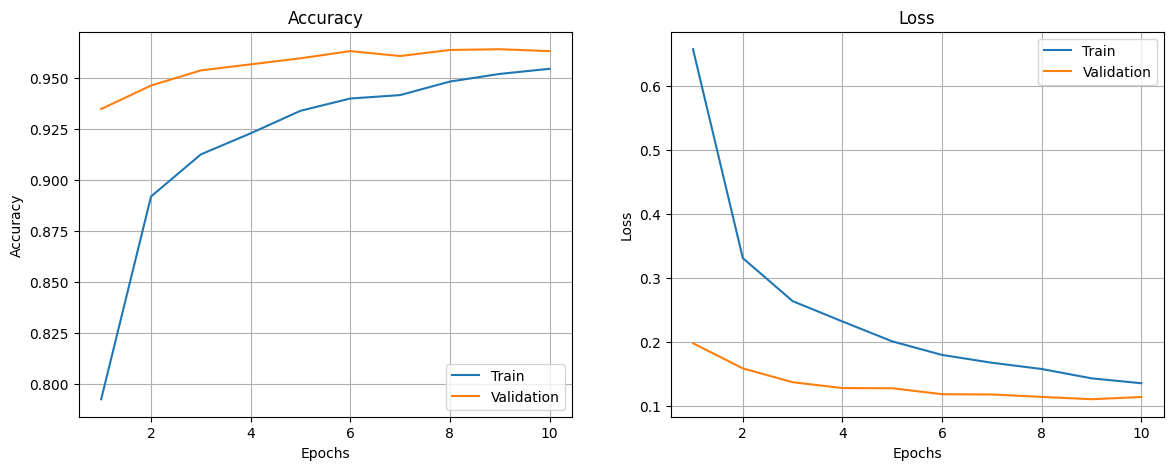

In [ ]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(history.history['accuracy']) + 1)

plt.figure(figsize=(14, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history.history['accuracy'], label='Train')
plt.plot(epochs_range, history.history['val_accuracy'], label='Validation')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()

# Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history.history['loss'], label='Train')
plt.plot(epochs_range, history.history['val_loss'], label='Validation')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()

plt.show()

### **3.5. Анализ результатов:**
  * Проанализируйте влияние различных параметров на производительность модели, таких как:
      * Количество эпох обучения
      * Размер пакета
      * Функция активации
      * Оптимизатор
      * Регуляризация

-----------------------------------------
**Ваш вывод**
-----------------------------------------


Количество эпох обучения оказывает существенное влияние на качество модели. При увеличении числа эпох наблюдается рост точности на обучающей выборке, однако после определённого момента улучшение замедляется, а при слишком большом числе эпох может возникнуть переобучение.

Размер пакета (batch size) влияет на стабильность и скорость обучения. При использовании небольшого размера пакета обучение становится более шумным, но может улучшить обобщающую способность модели. Большие значения batch size ускоряют обучение, однако могут привести к ухудшению качества.

Функция активации играет важную роль в обучении нейронной сети. В данной работе использовалась функция ReLU в скрытых слоях, которая обеспечивает эффективное обучение и предотвращает проблему затухающих градиентов. В выходном слое использовалась функция softmax, подходящая для задачи многоклассовой классификации.

Выбор оптимизатора также существенно влияет на результат. Использование оптимизатора Adam позволило добиться быстрой сходимости и стабильного обучения.

Регуляризация применяется для предотвращения переобучения. В данной работе использовался слой Dropout, который случайным образом отключает нейроны во время обучения.

Таким образом, корректный выбор гиперпараметров является ключевым фактором успешного обучения нейронной сети и позволяет достичь высокой точности классификации.